In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import gurobipy as gp
from gurobipy import GRB

# Project configuration (notebook is inside Game_1_Matthieu_VERNHES/)
DATA_PATH = "../data/dataset_G21.csv"
ANCHOR = "OJ=F"

# Load dataset (MultiIndex: Price Type -> Ticker)
df_raw = pd.read_csv(DATA_PATH, header=[0, 1], index_col=0, parse_dates=True)

# Extract prices and clean data
df_prices = df_raw.xs('Adj Close', axis=1, level=0)
df_prices = df_prices.ffill().dropna(axis=1, how='all').dropna()

# Compute daily returns
returns = df_prices.pct_change().dropna()

# Define the trading universe (exclude the anchor commodity)
universe = [col for col in df_prices.columns if col != ANCHOR]

print(f"Data loaded: {len(df_prices)} trading days.")
print(f"Universe size: {len(universe)} assets.")

Data loaded: 2083 trading days.
Universe size: 27 assets.


In [38]:
# Split data: 70% Formation (Train) / 30% Trading (Test)
split_idx = int(len(df_prices) * 0.7)
train_prices = df_prices.iloc[:split_idx]
train_rets = returns.iloc[:split_idx]

# Cointegration screening (Engle-Granger test)
p_values = {}
for stock in universe:
    _, p_val, _ = coint(train_prices[ANCHOR], train_prices[stock])
    p_values[stock] = p_val

# Select the top 5 most cointegrated assets (lowest p-values)
selected_stocks = sorted(p_values, key=p_values.get)[:5]

# Calculate Betas for the selected stocks using OLS
betas = {}
for stock in selected_stocks:
    X = sm.add_constant(train_rets[ANCHOR])
    model = sm.OLS(train_rets[stock], X).fit()
    betas[stock] = model.params[ANCHOR]

print(f"Top 5 cointegrated stocks: {selected_stocks}")
print("Historical Betas:", {s: round(betas[s], 4) for s in selected_stocks})

Top 5 cointegrated stocks: ['CC=F', 'SB=F', 'SJM', 'FIZZ', 'MNST']
Historical Betas: {'CC=F': -0.0301, 'SB=F': 0.0675, 'SJM': 0.001, 'FIZZ': -0.0053, 'MNST': 0.042}


In [39]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# Prepare inputs for optimization
cov_mat = train_rets[selected_stocks].cov().values
beta_vec = np.array([betas[s] for s in selected_stocks])

# Initialize Gurobi model
m = gp.Model("Portfolio_Optimization")
m.setParam('OutputFlag', 0) # Silence optimizer output

# Decision variables: portfolio weights (allowing shorting and leveraging)
w = m.addMVar(len(selected_stocks), lb=-2.0, ub=2.0)

# Objective: Minimize portfolio variance
m.setObjective(w @ cov_mat @ w, GRB.MINIMIZE)

# Constraint 1: Market neutrality (Sum of Beta * Weight = 0)
m.addConstr(w @ beta_vec == 0, name="Beta_Neutral")

# Constraint 2: Fully invested (Sum of weights = 1)
m.addConstr(w.sum() == 1, name="Fully_Invested")

# Solve the model
m.optimize()

if m.status == GRB.OPTIMAL:
    optimal_weights = w.X
    print("Optimal Weights:")
    for s, wt in zip(selected_stocks, optimal_weights):
        print(f"{s}: {wt:.4f}")
    
    # Sanity checks to include in the report
    print("\n--- Constraints Check ---")
    print(f"Total Weight: {np.sum(optimal_weights):.4f} (Target: 1.0)")
    print(f"Portfolio Beta: {np.dot(optimal_weights, beta_vec):.4f} (Target: 0.0)")
else:
    print("Optimization failed. Check input data.")

Optimal Weights:
CC=F: 0.3735
SB=F: 0.1181
SJM: 0.3667
FIZZ: 0.0639
MNST: 0.0779

--- Constraints Check ---
Total Weight: 1.0000 (Target: 1.0)
Portfolio Beta: 0.0000 (Target: 0.0)


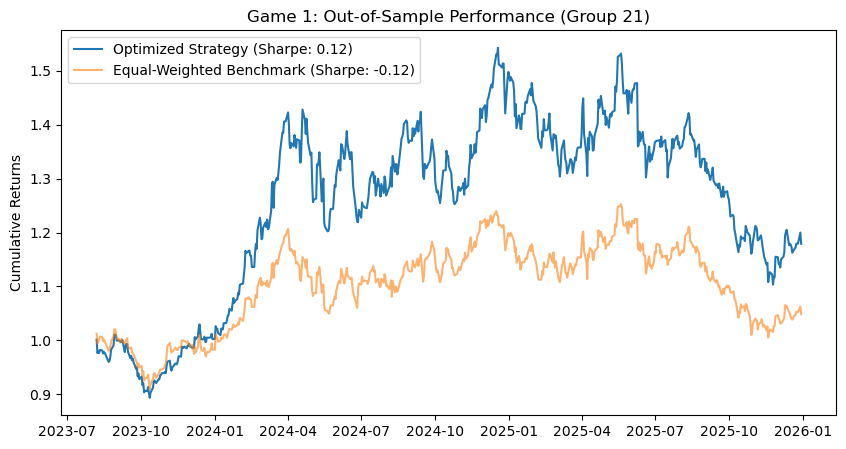

In [40]:
# Out-of-sample testing period (last 30%)
test_rets = returns[selected_stocks].iloc[split_idx:]
fees = 0.0010  # 10 bps transaction fee (paid once at entry)

# Calculate daily returns (gross)
strat_rets = test_rets @ optimal_weights
bench_rets = test_rets.mean(axis=1)

# Calculate cumulative returns (net of fees)
cum_strat = (1 + strat_rets).cumprod() * (1 - fees)
cum_bench = (1 + bench_rets).cumprod() * (1 - fees)

# Helper function to compute annualized Sharpe ratio (4% risk-free rate)
def get_sharpe(r, cum):
    ann_ret = (cum.iloc[-1]) ** (252 / len(r)) - 1
    vol = r.std() * np.sqrt(252)
    return (ann_ret - 0.04) / vol if vol > 1e-6 else 0.0

# Plot performance
plt.figure(figsize=(10, 5))
plt.plot(cum_strat, label=f"Optimized Strategy (Sharpe: {get_sharpe(strat_rets, cum_strat):.2f})")
plt.plot(cum_bench, label=f"Equal-Weighted Benchmark (Sharpe: {get_sharpe(bench_rets, cum_bench):.2f})", alpha=0.6)
plt.title("Game 1: Out-of-Sample Performance (Group 21)")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.show()